In [33]:
import csv
from builtins import open
def load_weights(filename: str):
    sg_wts = []
    rc_wts = []
    with open(filename, newline='') as csvfile:
        reader = csv.reader(csvfile)
        flag = True
        for row in reader:
            if flag:
                flag = False
            else:
                sg_wts.append([float(x) for x in row[4:7]])
                rc_wts.append([float(x) for x in row[7:]])
    return sg_wts, rc_wts

In [34]:
import numpy as np

# deduce the strategy of a single state
def deduce_strategy(sgw: list):
    a, b, c = sgw
    if (a >= 0.1 and b >= 0.1):
        return "0/1"
    elif (b >= 0.1 and c >= 0.1):
        return "1/null"
    elif (c >= 0.1 and a >= 0.1):
        return "0/null"
    return str(np.argmax(sgw))


def deduce_reci_action(acw: np.array):
    a = np.argmax(acw[:, 0])
    b = np.argmax(acw[:, 1])
    return (a, b)

In [35]:
def get_label(strat: list) -> list:
    lbls = []
    visited = set()
    seen = set()
    if strat[0] == "2":
        lbls.append("left edge")
    for i in range(1, len(strat)):
        # if we have "left edge" uncertainty, ignore
        if strat[i-1] == "2":
            continue

        # if we've been here before, skip
        # I'm only including this because Python is weird
        # about incrementing the iterator in a for loop.
        if i in visited:
            continue

        visited.add(i)
        choice = strat[i]

        if choice not in ["0", "1", "2"]:
            continue

        # if our current choice is the null signal, determine how large
        # the region is and then increment i to the end of the region.
        if choice == "2":
            j = i
            while j < len(strat) and strat[j] == "2":
                visited.add(j)
                j += 1
            
            if j == len(strat):
                # if we fall off the end, this is "right edge" uncertainty and we're done.
                lbls.append("right edge")
                break
            else:
                lbls.append(f"Vague between {i} and {j}")
                i = j # does this really work? - no

        # if the next choice in strategy is not the same as here,
        # we've reached the end of a contiguous region. 
        # if we've seen this type of region before, there is non-contiguity.
        if choice in seen:
            lbls.append(f"Non-contiguous {choice}")
        elif i+1 != len(strat) and choice != strat[i+1]:
            seen.add(choice)
        
            
    return lbls

In [36]:
def game_report(filename: str):
    signal_weights, reci_weights = load_weights(filename)

    strategy = []
    for i in range(len(signal_weights)):
        strategy.append(deduce_strategy(signal_weights[i]))

    reciever_strategy = deduce_reci_action(np.array(reci_weights))

    null_used = "2" in strategy
    mixed_signals = "mixed" in strategy
    label = get_label(strategy)
    both_signals = "0" in strategy

    print(" | ".join(strategy))
    print(reciever_strategy)
    print(f"Null used: {null_used}")
    print(f"Mixed signaling: {mixed_signals}")
    print(f"Labels: {', '.join(label)}")

In [37]:
from os import listdir
def get_stats_by_folder(folder: str):
    files = listdir(folder)
    files = [x for x in files if x[-3:] == "csv"]
    stats = {
        "vagueness": set(),
        "both_signals": set(),
        "one_signal": set(),
        "multiple_vague_regions": set(),
        "reciever_agreement": set(),
        "non_contiguity": set(),
        "no_signaling": set(),
        "edges": set()
    }
    for fi in files:
        sig_weights, reci_weights = load_weights(folder + fi)
        
        sender_strategy = []
        for i in range(len(sig_weights)):
            sender_strategy.append(deduce_strategy(sig_weights[i]))

        reciever_strategy = deduce_reci_action(np.array(reci_weights))
        labels = get_label(sender_strategy)

        vg_count = 0
        for label in labels:
            if label.startswith("Vague"):
                vg_count += 1
            elif label.startswith("Non-contiguous"):
                stats["non_contiguity"].add(fi)
            elif label.startswith("left") or label.startswith("right"):
                stats["edges"].add(fi)

        if vg_count > 1:
            stats["vagueness"].add(fi)
            stats["multiple_vague_regions"].add(fi)
        elif vg_count > 0:
            stats["vagueness"].add(fi)

        if "0" in sender_strategy and "1" in sender_strategy:
            stats["both_signals"].add(fi)
        elif "0" in sender_strategy or "1" in sender_strategy:
            stats["one_signal"].add(fi)
        else:
            stats["no_signaling"].add(fi)

        if reciever_strategy[0] == reciever_strategy[1]:
            stats["reciever_agreement"].add(fi)

    return stats

In [38]:
%matplotlib inline
import matplotlib.pyplot as plt
from PIL import Image

def display_game(filename: str):
    image = np.asarray(Image.open(filename))
    plt.imshow(image)
    plt.axis("off")
    plt.show()

# Without reciever stimgen

## d = 0.3
reward = 1 - 0.3x

In [39]:
directory = "./simulations/20_2_20/no_reciever_stimgen/30/"
stats_a = get_stats_by_folder(directory)

In [62]:
print(f"Vagueness: {len(stats_a['vagueness'])}")
print(f"Both Signals: {len(stats_a['both_signals'])}")
print(f"One Signal: {len(stats_a['one_signal'])}")
print(f"No Signals: {len(stats_a['no_signaling'])}")
print(f"Reciever Agreement: {len(stats_a['reciever_agreement'])}")
print(f"Non-contiguity: {len(stats_a['non_contiguity'])}")
print(f"Edges: {len(stats_a['edges'])}")

Vagueness: 3
Both Signals: 58
One Signal: 42
No Signals: 0
Reciever Agreement: 0
Non-contiguity: 0
Edges: 99


In [41]:
print(repr(stats_a["vagueness"]))

{'null_usage_1_0.3_97.csv', 'null_usage_1_0.3_44.csv', 'null_usage_1_0.3_68.csv'}


## d = 0.25
reward = 1 - 0.25x

In [42]:
directory = "./simulations/20_2_20/no_reciever_stimgen/25/"
stats_b = get_stats_by_folder(directory)

In [61]:
print(f"Vagueness: {len(stats_b['vagueness'])}")
print(f"Both Signals: {len(stats_b['both_signals'])}")
print(f"One Signal: {len(stats_b['one_signal'])}")
print(f"No Signals: {len(stats_b['no_signaling'])}")
print(f"Reciever Agreement: {len(stats_b['reciever_agreement'])}")
print(f"Non-contiguity: {len(stats_b['non_contiguity'])}")
print(f"Edges: {len(stats_b['edges'])}")

Vagueness: 5
Both Signals: 91
One Signal: 9
No Signals: 0
Reciever Agreement: 0
Non-contiguity: 0
Edges: 100


In [44]:
print(repr(stats_b["vagueness"]))

{'null_usage_1_0.25_49.csv', 'null_usage_1_0.25_64.csv', 'null_usage_1_0.25_8.csv', 'null_usage_1_0.25_35.csv', 'null_usage_1_0.25_75.csv'}


## d = 0.2
reward = 1 - 0.2x

In [45]:
directory = "./simulations/20_2_20/no_reciever_stimgen/20/"
stats_c = get_stats_by_folder(directory)

In [60]:
print(f"Vagueness: {len(stats_c['vagueness'])}")
print(f"Both Signals: {len(stats_c['both_signals'])}")
print(f"One Signal: {len(stats_c['one_signal'])}")
print(f"No Signals: {len(stats_c['no_signaling'])}")
print(f"Reciever Agreement: {len(stats_c['reciever_agreement'])}")
print(f"Non-contiguity: {len(stats_c['non_contiguity'])}")
print(f"Edges: {len(stats_c['edges'])}")

Vagueness: 2
Both Signals: 98
One Signal: 2
No Signals: 0
Reciever Agreement: 0
Non-contiguity: 0
Edges: 94


In [47]:
print(repr(stats_c["vagueness"]))

{'null_usage_1_0.2_87.csv', 'null_usage_1_0.2_0.csv'}


null_usage_1_0.2_87.csv
1 | 1 | 1 | 1 | 1 | 1 | 1 | 2 | 2 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0
(np.int64(14), np.int64(1))
Null used: True
Mixed signaling: False
Labels: Vague between 7 and 9


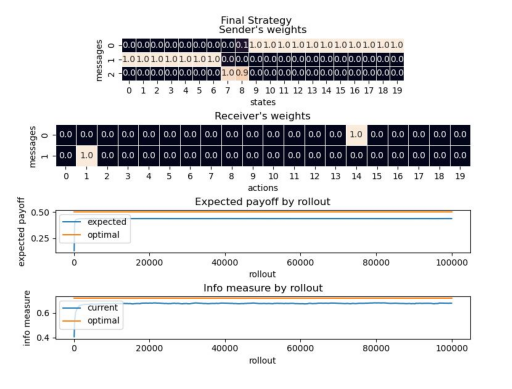

In [48]:
target_game = list(stats_c['vagueness'])[0]
print(target_game)
game_report(directory + target_game)
# I had to hardcode this, no brain cycles left
display_game(directory + "(1, 0.2)_null_100000_87.jpg")

# Receiver Stimgen

In [49]:
directory = "./simulations/20_2_20/reciever_stimgen/30/"
stats_ba = get_stats_by_folder(directory)

In [54]:
print(f"Vagueness: {len(stats_ba['vagueness'])}")
print(f"Both Signals: {len(stats_ba['both_signals'])}")
print(f"One Signal: {len(stats_ba['one_signal'])}")
print(f"No Signals: {len(stats_ba['no_signaling'])}")
print(f"Reciever Agreement: {len(stats_ba['reciever_agreement'])}")
print(f"Non-contiguity: {len(stats_ba['non_contiguity'])}")
print(f"Edges: {len(stats_ba['edges'])}")

Vagueness: 3
Both Signals: 50
One Signal: 50
No Signals: 0
Reciever Agreement: 1
Non-contiguity: 0
Edges: 99


In [51]:
print(repr(stats_ba["vagueness"]))

{'null_usage_1_0.3_43.csv', 'null_usage_1_0.3_89.csv', 'null_usage_1_0.3_55.csv'}


null_usage_1_0.3_43.csv
2 | 2 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 2 | 1/null | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1/null
(np.int64(5), np.int64(15))
Null used: True
Mixed signaling: False
Labels: left edge, Vague between 10 and 11


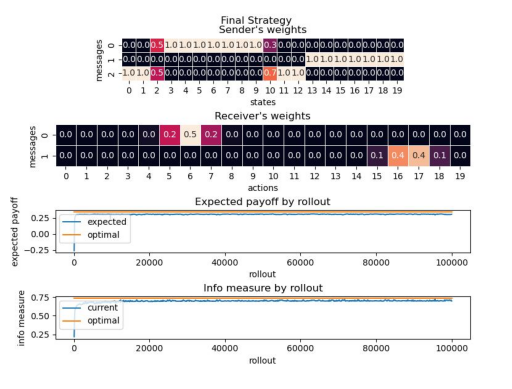

In [53]:
target_game = list(stats_ba['vagueness'])[0]
print(target_game)
game_report(directory + target_game)
# I had to hardcode this, no brain cycles left
display_game(directory + "(1, 0.3)_null_100000_89.jpg")

## d = 0.25
reward = 1 - 0.25x

In [56]:
directory = "./simulations/20_2_20/reciever_stimgen/25/"
stats_bb = get_stats_by_folder(directory)

In [57]:
print(f"Vagueness: {len(stats_bb['vagueness'])}")
print(f"Both Signals: {len(stats_bb['both_signals'])}")
print(f"One Signal: {len(stats_bb['one_signal'])}")
print(f"No Signals: {len(stats_bb['no_signaling'])}")
print(f"Reciever Agreement: {len(stats_bb['reciever_agreement'])}")
print(f"Non-contiguity: {len(stats_bb['non_contiguity'])}")
print(f"Edges: {len(stats_bb['edges'])}")

Vagueness: 3
Both Signals: 87
One Signal: 13
No Signals: 0
Reciever Agreement: 1
Non-contiguity: 0
Edges: 98


In [ ]:
print(repr(stats_bb["vagueness"]))

{'null_usage_1_0.25_55.csv', 'null_usage_1_0.25_62.csv', 'null_usage_1_0.25_18.csv'}


## d = 0.2
reward = 1 - 0.2x

In [58]:
directory = "./simulations/20_2_20/reciever_stimgen/20/"
stats_bc = get_stats_by_folder(directory)

In [59]:
print(f"Vagueness: {len(stats_bc['vagueness'])}")
print(f"Both Signals: {len(stats_bc['both_signals'])}")
print(f"One Signal: {len(stats_bc['one_signal'])}")
print(f"No Signals: {len(stats_bc['no_signaling'])}")
print(f"Reciever Agreement: {len(stats_bc['reciever_agreement'])}")
print(f"Non-contiguity: {len(stats_bc['non_contiguity'])}")
print(f"Edges: {len(stats_bc['edges'])}")

Vagueness: 3
Both Signals: 97
One Signal: 3
No Signals: 0
Reciever Agreement: 0
Non-contiguity: 0
Edges: 87


In [ ]:
print(repr(stats_bc["vagueness"]))

{'null_usage_1_0.2_89.csv', 'null_usage_1_0.2_95.csv', 'null_usage_1_0.2_83.csv'}


null_usage_1_0.2_89.csv
0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 2 | 1/null | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1
(np.int64(3), np.int64(16))
Null used: True
Mixed signaling: False
Labels: Vague between 9 and 10


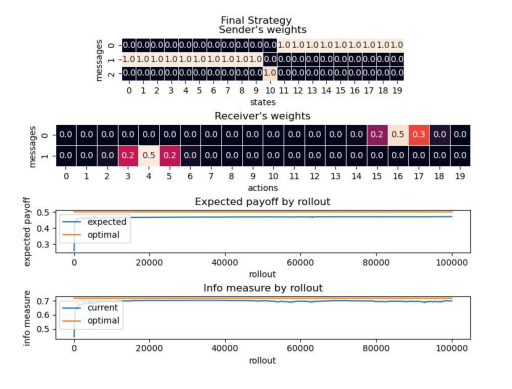

In [ ]:
target_game = list(stats_bc['vagueness'])[0]
print(target_game)
game_report(directory + target_game)
# I had to hardcode this, no brain cycles left
display_game(directory + "(1, 0.2)_null_100000_83.jpg")